## EDA and Data Cleaning

### Import Python Libraries and set properties for the notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import gc

In [2]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
# Force pandas to display 2 decimal places (no scientific notation)
pd.options.display.float_format = '{:.2f}'.format

### Import data from the raw file

In [3]:
#filepath = '../data/raw/neiss_combined_raw_untouched_data.csv'
#data_original = pd.read_csv(filepath, engine='pyarrow')
filepath = '../data/raw/neiss_original_raw_untouched_data.parquet'
data_original = pd.read_parquet(filepath)

In [4]:
# Deep copy to preserve original data
data = data_original.copy()
data1 = data_original.copy()

In [5]:
data1.columns

Index(['data_year', 'CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race',
       'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis',
       'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition',
       'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3',
       'Alcohol', 'Drug', 'Narrative_1', 'Stratum', 'PSU', 'Weight'],
      dtype='str')

In [6]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 26 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                int64         
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          int64         
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       
 

### Summary of Columns with NULL, Unknown and their Percentages

In [7]:
# 1. Define the specific "Missing Value" codes for NEISS dataset
neiss_missing_codes = {
    'Race': [0],
    'Sex': [0],
    'Location': [0],
    'Fire_Involvement': [0],
    'Disposition': [9]
}

def check_missing_data(df, specific_codes):
    report = []
    
    for col in df.columns:
        # 1. Count actual Nulls (NaN)
        null_count = df[col].isnull().sum()
        total_rows = len(df)
        null_percent = (null_count / total_rows) * 100
        
        # 2. Count "Code 0" (if applicable to this column)
        missing_data_count = 0
        if col in specific_codes:
            # Counts how many times the specific code (like 0) appears
            missing_data_count = df[col].isin(specific_codes[col]).sum()
            
        # 3. Calculate Totals
        total_missing = null_count + missing_data_count
        percent_missing = (total_missing / total_rows) * 100
        
        report.append({
            'Column Name': col,
            'Null Count': null_count,
            'Null %': round(null_percent, 2),
            'Unknown Count': missing_data_count,
            'Total_Missing(Null & Unknown)': total_missing,
            'Percentage Missing': round(percent_missing, 2)
        })
        
    return pd.DataFrame(report).sort_values('Percentage Missing', ascending=False)

# Run the check
missing_report = check_missing_data(data1, neiss_missing_codes)
pd.DataFrame(missing_report)

,Column Name,Null Count,Null %,Unknown Count,Total_Missing(Null & Unknown),Percentage Missing
16,Fire_Involvement,0,0.00,7283693,7283693,99.56
13,Other_Diagnosis_2,7214095,98.61,0,7214095,98.61
12,Diagnosis_2,6866693,93.86,0,6866693,93.86
11,Body_Part_2,6866693,93.86,0,6866693,93.86
6,Other_Race,6821041,93.24,0,6821041,93.24
10,Other_Diagnosis,6329255,86.52,0,6329255,86.52
20,Alcohol,5283928,72.23,0,5283928,72.23
21,Drug,5283928,72.23,0,5283928,72.23
7,Hispanic,5283928,72.23,0,5283928,72.23
5,Race,0,0.00,2145028,2145028,29.32


### 1. Handling NULL Data in the file <br>

In [8]:
null_data = data.isnull().sum().reset_index()
null_data.columns = ['Column_Name', 'Count']
null_data = null_data[null_data['Count'] > 0]
null_data

,Column_Name,Count
6,Other_Race,6821041
7,Hispanic,5283928
10,Other_Diagnosis,6329255
11,Body_Part_2,6866693
12,Diagnosis_2,6866693
13,Other_Diagnosis_2,7214095
20,Alcohol,5283928
21,Drug,5283928


#### The above list of features have null values that needs to be handled. <br>


#### 1.1 NULL Values in Other_Race Feature
Other Race feature is a string field which lists the description of other race if the race used in the Race field is 3. Hence, update the Other_Race with a NULL value as "UNKNOWN"

In [9]:
print(f'Null values in Other_Race Feature before change:{data1["Other_Race"].isnull().sum()}') 
data1['Other_Race'] = data1['Other_Race'].fillna('UNKNOWN')
print(f'Null values in Other_Race Feature after change:{data1["Other_Race"].isnull().sum()}') 

Null values in Other_Race Feature before change:6821041
Null values in Other_Race Feature after change:0


#### 1.2. Handle NULL values in Hispanic Feature

Fill the NULL records with 0.0 - Unknown.

In [10]:
print(data1.Hispanic.value_counts())
print(f'Null values in Hispanic Feature before change:{data1["Hispanic"].isnull().sum()}') 
data1['Hispanic'] = data1['Hispanic'].fillna('0.0')
data1['Hispanic'] = data1['Hispanic'].astype(float)
print(f'Null values in Hispanic Feature after change:{data1["Hispanic"].isnull().sum()}')
print(data1.Hispanic.value_counts())

Hispanic
2.00    1231235
0.00     586760
1.00     213809
Name: count, dtype: int64
Null values in Hispanic Feature before change:5283928
Null values in Hispanic Feature after change:0
Hispanic
0.00    5870688
2.00    1231235
1.00     213809
Name: count, dtype: int64


#### 1.3 Handle NULL values in Other_Diagnosis Feature

In [11]:
print(f'Null values in Other_Diagnosis Feature before change:{data1["Other_Diagnosis"].isnull().sum()}') 
data1['Other_Diagnosis'] = data1['Other_Diagnosis'].fillna('UNKNOWN')
print(f'Null values in Other_Diagnosis Feature after change:{data1["Other_Diagnosis"].isnull().sum()}') 

Null values in Other_Diagnosis Feature before change:6329255
Null values in Other_Diagnosis Feature after change:0


#### 1.4. Handle NULL values in Body_Part_2 Feature

In [12]:
print(f'Null values in Body_Part_2 Feature before change:{data1["Body_Part_2"].isnull().sum()}') 
data1['Body_Part_2'] = data1['Body_Part_2'].fillna(87.0)
data1['Body_Part_2'] = data1['Body_Part_2'].astype(float)
print(f'Null values in Body_Part_2 Feature after change:{data1["Body_Part_2"].isnull().sum()}') 

Null values in Body_Part_2 Feature before change:6866693
Null values in Body_Part_2 Feature after change:0


#### 1.5. Handle NULL values in Diagnosis_2 Feature

In [13]:
print(f'Null values in Diagnosis_2 Feature before change:{data1["Diagnosis_2"].isnull().sum()}') 
data1['Diagnosis_2'] = data1['Diagnosis_2'].fillna(71.0)
print(f'Null values in Diagnosis_2 Feature after change:{data1["Diagnosis_2"].isnull().sum()}')

Null values in Diagnosis_2 Feature before change:6866693
Null values in Diagnosis_2 Feature after change:0


#### 1.6. Handle NULL values in Other_Diagnosis_2 Feature

In [14]:
print(f'Null values in Other_Diagnosis_2 Feature before change:{data1["Other_Diagnosis_2"].isnull().sum()}') 
data1['Other_Diagnosis_2'] = data1['Other_Diagnosis_2'].fillna('UNKNOWN')
print(f'Null values in Other_Diagnosis_2 Feature after change:{data1["Other_Diagnosis_2"].isnull().sum()}') 

Null values in Other_Diagnosis_2 Feature before change:7214095
Null values in Other_Diagnosis_2 Feature after change:0


#### 1.7. Handle NULL values in the Alcohol Feature 

In [15]:
print(f'Null values in Alcohol Feature before change:{data1["Alcohol"].isnull().sum()}') 
data1['Alcohol'] = data1['Alcohol'].fillna(3)
print(f'Null values in Alcohol Feature after change:{data1["Alcohol"].isnull().sum()}') 
print(data1['Alcohol'].value_counts())

Null values in Alcohol Feature before change:5283928
Null values in Alcohol Feature after change:0
Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64


#### 1.8. Null values in the Drug Feature 

In [16]:
print(f'Null values in Drug Feature before change:{data1["Drug"].isnull().sum()}') 
data1['Drug'] = data1['Drug'].fillna(3)
print(f'Null values in Alcohol Feature after change:{data1["Drug"].isnull().sum()}') 
print(data1['Drug'].value_counts())

Null values in Drug Feature before change:5283928
Null values in Alcohol Feature after change:0
Drug
3.00    5283928
0.00    1986756
1.00      45048
Name: count, dtype: int64


#### Validate if all the null values are fixed

In [17]:
missing_report = check_missing_data(data1, neiss_missing_codes)
missing_report_df = pd.DataFrame(missing_report)
missing_report_df[missing_report_df['Null Count'] > 0]

,Column Name,Null Count,Null %,Unknown Count,Total_Missing(Null & Unknown),Percentage Missing


No null values exist in the data.

### 2. Handle Unknown Values (If Needed)

In [18]:
missing_report_df[missing_report_df['Total_Missing(Null & Unknown)'] > 0]
#missing_report_df[['Column Name','Total_Missing(Null & Unknown)','Percentage Missing']]

,Column Name,Null Count,Null %,Unknown Count,Total_Missing(Null & Unknown),Percentage Missing
16,Fire_Involvement,0,0.00,7283693,7283693,99.56
5,Race,0,0.00,2145028,2145028,29.32
15,Location,0,0.00,2099509,2099509,28.70
14,Disposition,0,0.00,382,382,0.01
4,Sex,0,0.00,978,978,0.01


#### 2.1 Handle unknown values in Fire_Involvement Feature

In [19]:
data1.fire_involvement.value_counts()

AttributeError: 'DataFrame' object has no attribute 'fire_involvement'

#### 2.2 Handle unknown values in Race Feature

#### 2.3 Handle unknown values in Location Feature

#### 2.4 Handle unknown values in Disposition Feature

#### 2.5 Handle unknown values in Sex Feature

### 3. Check for Duplicates

In [ ]:
duplicated_rows = data1[data1.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows: 0


No need to remove duplicate records as the data doesnt have any duplicates

### 3. EDA and Data Cleaning

#### 3.1 Handle Age Feature <br>
Perfrom conversion of age in months to years and decide if we need to handle "Age not recorded" 0 Age.

According to the data dictionary, the age is 0 if not recorded, it is 2 and 120 in years or it is recorded in months 0f 201 - 223 for age < 2 years.

We need to make Age into a uniform scale of years. To do this, we will convert the age < 2 years.

In [ ]:
def convert_age(age):
    if age >200:
        new_age = (age-200)/12 
    else:
        new_age = age 
    return new_age
data1['True_Age'] = data1['Age'].apply(convert_age)

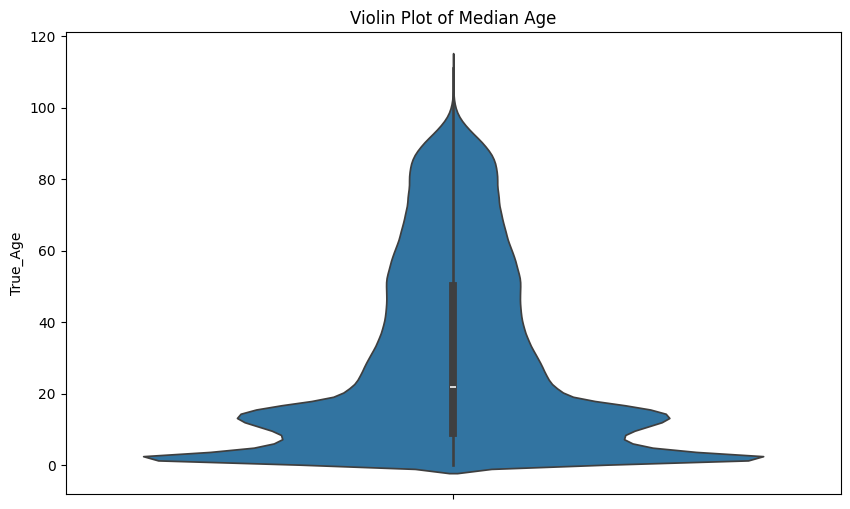

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=data1, y="True_Age")
plt.title("Violin Plot of Median Age")
plt.show()


Check how many records has zero age and decide how to handle the records with missing age.

In [ ]:
zero_age_count = data1[data1[['True_Age']].True_Age == 0].shape
print(f'Count of records with zero age:{zero_age_count[0]}')
median_age = data1['True_Age'].median().round(2)
print(f'Median Age:{median_age}')

Count of records with zero age:504
Median Age:22.0


As the count of records with age =0 is around 500 we can either drop them or can fill it with the median age.

In [ ]:
data1['True_Age'] = data1['True_Age'].replace(0, median_age)
zero_age_count = data1[data1[['True_Age']].True_Age == 0].shape
print(f'Count of records with zero age:{zero_age_count[0]}')

Count of records with zero age:0


In [ ]:
import pandas as pd

# 1. Define the specific "Missing Value" codes for NEISS
#    Most NEISS columns use 0 for "Not Stated" or "Unknown"
neiss_missing_codes = {
    'Race': [0],
    'Sex': [0],
    'Location': [0],
    'Fire_Involvement': [0],
    'Disposition': [9]
}

def check_missing_data(df, specific_codes):
    report = []
    
    for col in df.columns:
        # 1. Count actual Nulls (NaN)
        null_count = df[col].isnull().sum()
        total_rows = len(df)
        
        # 2. Count "Code 0" (if applicable to this column)
        code_missing_count = 0
        if col in specific_codes:
            # Counts how many times the specific code (like 0) appears
            code_missing_count = df[col].isin(specific_codes[col]).sum()
            
        # 3. Calculate Totals
        total_missing = null_count + code_missing_count
        percent_missing = (total_missing / total_rows) * 100
        
        report.append({
            'Column': col,
            'Actual_Nulls': null_count,
            'Code_Zero_Count': code_missing_count,
            'Total_Missing': total_missing,
            '%_Missing': round(percent_missing, 2)
        })
        
    return pd.DataFrame(report).sort_values('%_Missing', ascending=False)

# Run the check
missing_report = check_missing_data(data1, neiss_missing_codes)
print(missing_report)

               Column  Actual_Nulls  Code_Zero_Count  Total_Missing  %_Missing
16   Fire_Involvement             0          7283693        7283693      99.56
5                Race             0          2145028        2145028      29.32
15           Location             0          2099509        2099509      28.70
4                 Sex             0              978            978       0.01
14        Disposition             0              382            382       0.01
0           data_year             0                0              0       0.00
25             Weight             0                0              0       0.00
24                PSU             0                0              0       0.00
23            Stratum             0                0              0       0.00
22        Narrative_1             0                0              0       0.00
21               Drug             0                0              0       0.00
20            Alcohol             0                0

### 4. Save the data to the interim folder for future use

In [ ]:
#data1.to_csv('../data/interim/neiss_interim_data.csv', index=False)
data1.to_parquet('../data/interim/neiss_interim_data.parquet')
n = gc.collect()
print(f"Number of unreachable objects collected: {n}")

Number of unreachable objects collected: 2866
